# Grammar Scoring Engine for Spoken Audio (SHL Hiring Assessment 2026)

**Goal:** predict a continuous MOS Likert grammar score (0 to 5) from a 45 to 60 second audio clip.

**Approach in one paragraph:** Grammar lives mostly in the words, so I transcribe each clip with Whisper, then measure the text (fluency, fillers, repetition, sentence structure, language model perplexity, optional grammar rule errors) and embed it with a sentence encoder. I also take wav2vec2 audio embeddings to capture hesitation and delivery. Several regressors are trained with stratified 5 fold cross validation, blended, and evaluated with **RMSE and Pearson correlation**, the two leaderboard metrics. The final report is at the bottom.

**Notebook map**
1. Setup and data loading
2. Exploratory analysis
3. Transcription (Whisper)
4. Feature engineering (text, perplexity, embeddings, audio)
5. Optional Gemini grader feature
6. Modelling with cross validation
7. Training RMSE (compulsory) and diagnostics
8. Submission file
9. Report

## 1. Setup and data loading

In [1]:
# Run once on Kaggle (turn on GPU and Internet in the notebook settings).
!pip install -q faster_whisper sentence-transformers language_tool_python google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 58.1 MB/s eta 0:00:00


In [2]:
import os, re, glob, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import librosa, torch
from tqdm.auto import tqdm
from scipy.stats import pearsonr
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SR = 16000
WORK = "/kaggle/working" if os.path.exists("/kaggle") else "./work"
os.makedirs(WORK, exist_ok=True)
print("Device:", DEVICE)

Device: cuda


In [3]:
# Locate the competition folder automatically.
# Find the folder that contains train.csv, wherever Kaggle mounts it (searches any depth).
hits = glob.glob("/kaggle/input/**/train.csv", recursive=True)
ROOT = os.path.dirname(hits[0]) if hits else "."     # change "." if you run locally
print("ROOT:", ROOT)
assert os.path.exists(f"{ROOT}/train.csv"), "train.csv not found, add the competition data to this notebook"

train = pd.read_csv(f"{ROOT}/train.csv")
test = pd.read_csv(f"{ROOT}/test.csv")
sub = pd.read_csv(f"{ROOT}/sample_submission.csv")
print(train.shape, test.shape, sub.shape)
display(train.head()); display(sub.head())

# Column names are detected, not assumed.
ID_COL = train.columns[0]
TARGET = [c for c in train.columns[1:] if pd.api.types.is_numeric_dtype(train[c])][0]
print("ID column:", ID_COL, "| target column:", TARGET)

# IMPORTANT: train and test folders reuse the same file names (for example audio_128.wav
# exists in both, with different audio). Paths are therefore resolved per split.
def stem(x):
    return os.path.splitext(os.path.basename(str(x)))[0]

WAVS = {"train": {}, "test": {}}
for p in glob.glob(f"{ROOT}/**/*.wav", recursive=True):
    parts = os.path.normpath(os.path.relpath(p, ROOT)).split(os.sep)
    split = "train" if "train" in parts else "test" if "test" in parts else None
    if split:
        WAVS[split][stem(p)] = p

def wav_path(name, split):
    return WAVS[split][stem(name)]

print({k: len(v) for k, v in WAVS.items()})
assert len(WAVS["train"]) == len(train) and len(WAVS["test"]) == len(test), "folder split not detected correctly"

ROOT: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final
(769, 2) (216, 2) (204, 2)


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1


ID column: filename | target column: label
{'train': 769, 'test': 216}


## 2. Exploratory analysis

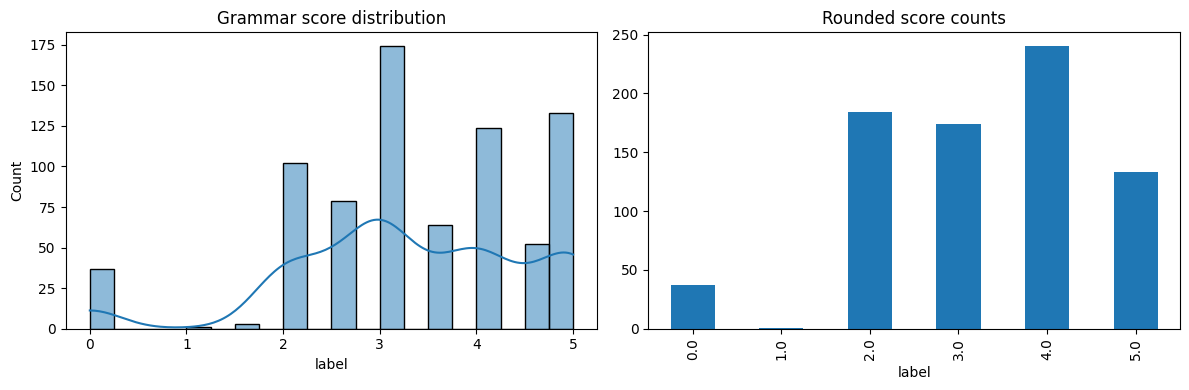

count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train[TARGET], bins=20, kde=True, ax=ax[0]); ax[0].set_title("Grammar score distribution")
train[TARGET].round().value_counts().sort_index().plot.bar(ax=ax[1]); ax[1].set_title("Rounded score counts")
plt.tight_layout(); plt.show()
print(train[TARGET].describe())

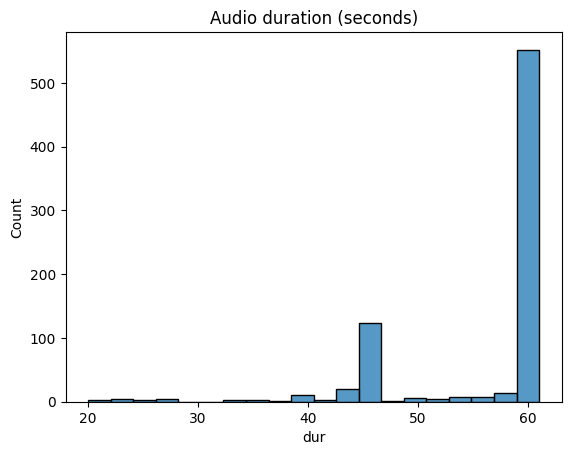

Correlation of duration with score: 0.087


In [5]:
# Clip durations (fast, reads headers only).
train["dur"] = [librosa.get_duration(path=wav_path(n, "train")) for n in train[ID_COL]]
sns.histplot(train["dur"], bins=20); plt.title("Audio duration (seconds)"); plt.show()
print("Correlation of duration with score:", round(train["dur"].corr(train[TARGET]), 3))

## 3. Transcription with Whisper

`faster_whisper` is used for speed. Transcripts are cached to disk so the expensive step runs once.
Word level timestamps give speaking rate and pause features, and the average log probability of each segment is a useful confidence signal (garbled grammar tends to lower it).

In [6]:
from faster_whisper import WhisperModel

asr = WhisperModel("small", device=DEVICE, compute_type="float16" if DEVICE == "cuda" else "int8")

def transcribe(path):
    # Decode with librosa and pass a numpy array, which avoids the PyAV version clash.
    audio, _ = librosa.load(path, sr=SR, mono=True)
    audio = audio.astype(np.float32)
    segs, info = asr.transcribe(audio, language="en", beam_size=5, word_timestamps=True,
                                vad_filter=False, condition_on_previous_text=False)
    segs = list(segs)
    text = " ".join(s.text.strip() for s in segs).strip()
    words = [w for s in segs for w in (s.words or [])]
    starts = [w.start for w in words]; ends = [w.end for w in words]
    gaps = [starts[i+1] - ends[i] for i in range(len(words) - 1)]
    return dict(
        text=text,
        n_words_asr=len(words),
        avg_logprob=float(np.mean([s.avg_logprob for s in segs])) if segs else -5.0,
        no_speech=float(np.mean([s.no_speech_prob for s in segs])) if segs else 1.0,
        n_pauses=int(sum(g > 0.5 for g in gaps)),
        long_pauses=int(sum(g > 1.0 for g in gaps)),
        mean_gap=float(np.mean(gaps)) if gaps else 0.0,
        speech_span=float(ends[-1] - starts[0]) if words else 0.0,
    )

def run_asr(df, cache, split):
    if os.path.exists(cache):
        return pd.read_csv(cache)
    rows = []
    for n in tqdm(df[ID_COL], desc="ASR"):
        r = transcribe(wav_path(n, split)); r[ID_COL] = n; rows.append(r)
    out = pd.DataFrame(rows); out.to_csv(cache, index=False); return out

# New cache names on purpose, so any transcripts from the buggy loader are ignored.
tr_asr = run_asr(train, f"{WORK}/asr_train_v2.csv", "train")
te_asr = run_asr(test, f"{WORK}/asr_test_v2.csv", "test")
tr_asr["text"] = tr_asr["text"].fillna(""); te_asr["text"] = te_asr["text"].fillna("")
display(tr_asr[[ID_COL, "text"]].head(3))

ASR:   0%|          | 0/769 [00:00<?, ?it/s]

ASR:   0%|          | 0/216 [00:00<?, ?it/s]

,filename,text
0,audio_192.wav,"Well, the playground is very, very beautiful a..."
1,audio_436.wav,"The scene of a school playground, our playgrou..."
2,audio_447.wav,My favorite place to visit is the beach. I lov...


## 4. Feature engineering

Four feature families:
* **Handcrafted text and speech features:** length, speaking rate, vocabulary richness, fillers, repetitions, sentence structure, pauses.
* **Language model perplexity (GPT 2):** ungrammatical text is less predictable, so perplexity is a direct fluency proxy.
* **Grammar rule errors (LanguageTool):** counts of flagged errors per word. Skipped automatically if Java or internet is unavailable.
* **Embeddings:** sentence transformer on the transcript and wav2vec2 on the raw audio.

In [7]:
FILLERS = {"um", "uh", "er", "erm", "hmm", "ah", "like", "basically", "actually", "you know"}
def text_features(t):
    t = t or ""
    words = re.findall(r"[A-Za-z']+", t.lower())
    n = max(len(words), 1)
    sents = [s for s in re.split(r"[.!?]+", t) if s.strip()]
    sl = [len(re.findall(r"[A-Za-z']+", s)) for s in sents] or [0]
    bigrams = list(zip(words, words[1:]))
    repeats_adj = sum(1 for a, b in bigrams if a == b)
    rep_bigram = 1 - len(set(bigrams)) / max(len(bigrams), 1)
    return dict(
        n_words=len(words), n_chars=len(t), n_sents=len(sents),
        avg_sent_len=float(np.mean(sl)), max_sent_len=int(np.max(sl)), std_sent_len=float(np.std(sl)),
        ttr=len(set(words)) / n, avg_word_len=float(np.mean([len(w) for w in words])) if words else 0,
        long_word_ratio=sum(len(w) > 6 for w in words) / n,
        filler_ratio=sum(w in FILLERS for w in words) / n,
        repeat_adj=repeats_adj, rep_bigram=rep_bigram,
        comma_ratio=t.count(",") / n,
        cap_sent_ratio=sum(s.strip()[:1].isupper() for s in sents) / max(len(sents), 1),
        conj_ratio=sum(w in {"and","but","because","so","although","which","that","while","if"} for w in words) / n,
        past_ratio=sum(w.endswith("ed") for w in words) / n,
        pron_ratio=sum(w in {"i","he","she","they","we","you","it"} for w in words) / n,
    )

def build_basic(asr_df):
    tf = pd.DataFrame([text_features(t) for t in asr_df["text"]])
    sp = asr_df[["avg_logprob","no_speech","n_pauses","long_pauses","mean_gap","speech_span"]].reset_index(drop=True)
    f = pd.concat([tf, sp], axis=1)
    f["wpm"] = f["n_words"] / np.maximum(f["speech_span"], 1) * 60
    f["pauses_per_word"] = f["n_pauses"] / np.maximum(f["n_words"], 1)
    return f

Xb_tr, Xb_te = build_basic(tr_asr), build_basic(te_asr)
print(Xb_tr.shape)

(769, 25)


In [8]:
# GPT 2 perplexity as a fluency and grammaticality proxy.
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
tok = GPT2TokenizerFast.from_pretrained("gpt2"); lm = GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE).eval()

@torch.no_grad()
def ppl_feats(t):
    ids = tok(t if t.strip() else "empty", return_tensors="pt", truncation=True, max_length=512).input_ids.to(DEVICE)
    logits = lm(ids).logits[:, :-1]
    nll = torch.nn.functional.cross_entropy(logits[0], ids[0, 1:], reduction="none").cpu().numpy()
    return dict(ppl_mean=float(np.mean(nll)) if len(nll) else 0, ppl_med=float(np.median(nll)) if len(nll) else 0,
                ppl_p90=float(np.percentile(nll, 90)) if len(nll) else 0, ppl_std=float(np.std(nll)) if len(nll) else 0)

P_tr = pd.DataFrame([ppl_feats(t) for t in tqdm(tr_asr["text"], desc="ppl train")])
P_te = pd.DataFrame([ppl_feats(t) for t in tqdm(te_asr["text"], desc="ppl test")])
del lm; torch.cuda.empty_cache()

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

ppl train:   0%|          | 0/769 [00:00<?, ?it/s]

ppl test:   0%|          | 0/216 [00:00<?, ?it/s]

In [9]:
# Grammar rule errors with LanguageTool (optional, degrades gracefully).
def lt_features(texts):
    try:
        import language_tool_python
        tool = language_tool_python.LanguageTool("en-US")
        out = []
        for t in tqdm(texts, desc="LanguageTool"):
            m = tool.check(t); n = max(len(t.split()), 1)
            cats = [x.category for x in m]
            out.append(dict(lt_err=len(m) / n, lt_gram=cats.count("GRAMMAR") / n,
                            lt_typo=cats.count("TYPOS") / n, lt_punct=cats.count("PUNCTUATION") / n,
                            lt_style=cats.count("STYLE") / n))
        return pd.DataFrame(out)
    except Exception as e:
        print("LanguageTool unavailable, using zeros:", type(e).__name__)
        return pd.DataFrame(0.0, index=range(len(texts)), columns=["lt_err","lt_gram","lt_typo","lt_punct","lt_style"])

L_tr, L_te = lt_features(tr_asr["text"].tolist()), lt_features(te_asr["text"].tolist())

LanguageTool:   0%|          | 0/769 [00:00<?, ?it/s]

LanguageTool:   0%|          | 0/216 [00:00<?, ?it/s]

In [10]:
# Sentence embeddings of the transcript.
from sentence_transformers import SentenceTransformer
st = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=DEVICE)
E_tr = st.encode(tr_asr["text"].tolist(), batch_size=32, show_progress_bar=True, normalize_embeddings=True)
E_te = st.encode(te_asr["text"].tolist(), batch_size=32, show_progress_bar=True, normalize_embeddings=True)
del st; torch.cuda.empty_cache(); print(E_tr.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

(769, 768)


In [11]:
# wav2vec2 audio embeddings: mean and std pooled over time from a middle and the last layer.
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model
fe = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
w2v = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(DEVICE).eval()

@torch.no_grad()
def audio_emb(path):
    y, _ = librosa.load(path, sr=SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    x = fe(y, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE)
    hs = w2v(x, output_hidden_states=True).hidden_states
    feats = []
    for layer in (6, 12):
        h = hs[layer][0]
        feats += [h.mean(0), h.std(0)]
    return torch.cat(feats).cpu().numpy()

A_tr = np.stack([audio_emb(wav_path(n, "train")) for n in tqdm(train[ID_COL], desc="w2v train")])
A_te = np.stack([audio_emb(wav_path(n, "test")) for n in tqdm(test[ID_COL], desc="w2v test")])
del w2v; torch.cuda.empty_cache(); print(A_tr.shape)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


w2v train:   0%|          | 0/769 [00:00<?, ?it/s]

w2v test:   0%|          | 0/216 [00:00<?, ?it/s]

(769, 3072)


## 5. Optional: Gemini grader as an extra feature

An LLM reading the transcript can judge grammar against the rubric. It is used only as **one more feature** for the regressors, never as the final answer. Set `USE_GEMINI = True` and provide `GEMINI_API_KEY` (Kaggle Secrets or environment variable) to enable it. Results are cached.

In [12]:
USE_GEMINI = False   # flip to True to enable

RUBRIC = '''Score the speaker's GRAMMAR from 1 to 5 using this rubric.
1 struggles with sentence structure, only memorised patterns.
2 limited control, consistent basic mistakes, incomplete sentences.
3 decent grasp, but errors in grammar or in sentence structure.
4 strong control, only minor occasional errors, mostly self corrected.
5 high accuracy, complex grammar used well, seldom noticeable mistakes.
The text is an automatic transcript of speech, so ignore punctuation and capitalisation.
Reply with ONLY a number between 1 and 5, decimals allowed.'''

def gemini_scores(texts, cache):
    if os.path.exists(cache):
        return pd.read_csv(cache)["gemini"].values
    from google import genai
    from google.genai import types
    key = os.environ.get("GEMINI_API_KEY")
    if key is None:
        from kaggle_secrets import UserSecretsClient
        key = UserSecretsClient().get_secret("GEMINI_API_KEY")
    client = genai.Client(api_key=key)
    out = []
    for t in tqdm(texts, desc="Gemini"):
        try:
            r = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=f"Transcript:\n{t}",
                config=types.GenerateContentConfig(system_instruction=RUBRIC, temperature=0.0))
            out.append(float(re.findall(r"\d+(?:\.\d+)?", r.text)[0]))
        except Exception:
            out.append(np.nan)
    pd.DataFrame({"gemini": out}).to_csv(cache, index=False)
    return np.array(out)

if USE_GEMINI:
    g_tr = gemini_scores(tr_asr["text"].tolist(), f"{WORK}/gem_train_v2.csv")
    g_te = gemini_scores(te_asr["text"].tolist(), f"{WORK}/gem_test_v2.csv")
    fill = np.nanmean(g_tr)
    G_tr = pd.DataFrame({"gemini": np.nan_to_num(g_tr, nan=fill)}); G_te = pd.DataFrame({"gemini": np.nan_to_num(g_te, nan=fill)})
else:
    G_tr = G_te = None

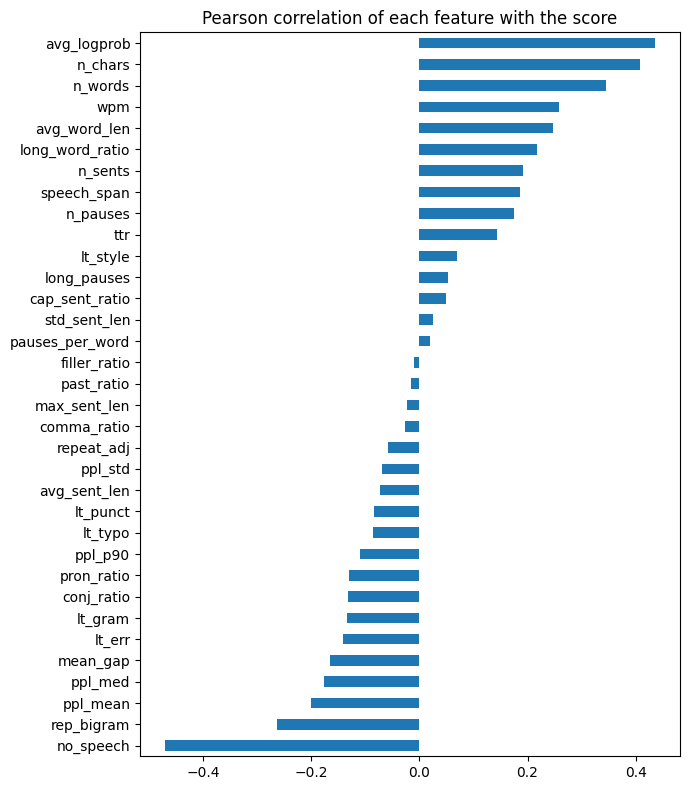

In [13]:
# Assemble the tabular block and quickly inspect which features matter.
parts_tr = [Xb_tr, P_tr, L_tr] + ([G_tr] if G_tr is not None else [])
parts_te = [Xb_te, P_te, L_te] + ([G_te] if G_te is not None else [])
H_tr = pd.concat(parts_tr, axis=1).fillna(0); H_te = pd.concat(parts_te, axis=1).fillna(0)
y = train[TARGET].values.astype(float)

corr = H_tr.corrwith(pd.Series(y)).sort_values()
plt.figure(figsize=(7, 8)); corr.plot.barh(); plt.title("Pearson correlation of each feature with the score"); plt.tight_layout(); plt.show()

## 6. Modelling with cross validation

Three complementary models are trained on out of fold splits (stratified on the rounded score):
* **Ridge** on everything (scaled), strong for high dimensional embeddings.
* **SVR (RBF)** on everything, captures non linear structure.
* **Gradient boosting** on handcrafted features plus PCA compressed embeddings.

Out of fold predictions are blended by non negative weights fitted on the OOF predictions, then clipped to the valid range.

In [14]:
from scipy.optimize import nnls

X_all_tr = np.hstack([H_tr.values, E_tr, A_tr]); X_all_te = np.hstack([H_te.values, E_te, A_te])

def make_ridge(): return make_pipeline(StandardScaler(), Ridge(alpha=3000))
def make_svr():   return make_pipeline(StandardScaler(), SVR(C=3.0, epsilon=0.2, gamma="scale"))

def gbm_view(train_idx, Xtr_h, Etr, Atr, Xte_h, Ete, Ate):
    pe = PCA(24, random_state=SEED).fit(Etr); pa = PCA(24, random_state=SEED).fit(Atr)
    f = lambda h, e, a: np.hstack([h, pe.transform(e), pa.transform(a)])
    return f(Xtr_h, Etr, Atr), f(Xte_h, Ete, Ate)

def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
def evaluate(name, y_true, pred):
    pred = np.clip(pred, 0, 5)
    print(f"{name:10s} RMSE={rmse(y_true, pred):.4f}  Pearson={pearsonr(y_true, pred)[0]:.4f}")

strata = np.clip(np.round(y), 0, 5).astype(int)
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
oof = {k: np.zeros(len(y)) for k in ["ridge", "svr", "gbm"]}
pred_te = {k: np.zeros(len(X_all_te)) for k in oof}

for fold, (tri, vai) in enumerate(skf.split(X_all_tr, strata)):
    for name, mk in [("ridge", make_ridge), ("svr", make_svr)]:
        m = mk().fit(X_all_tr[tri], y[tri])
        oof[name][vai] = m.predict(X_all_tr[vai]); pred_te[name] += m.predict(X_all_te) / 5
    Gtr, Gva = gbm_view(tri, H_tr.values[tri], E_tr[tri], A_tr[tri], H_tr.values[vai], E_tr[vai], A_tr[vai])
    _, Gte = gbm_view(tri, H_tr.values[tri], E_tr[tri], A_tr[tri], H_te.values, E_te, A_te)
    g = HistGradientBoostingRegressor(max_depth=4, learning_rate=0.04, max_iter=400, l2_regularization=1.0, random_state=SEED).fit(Gtr, y[tri])
    oof["gbm"][vai] = g.predict(Gva); pred_te["gbm"] += g.predict(Gte) / 5
    print(f"fold {fold} done")

print("\nCross validation (out of fold):")
for k in oof: evaluate(k, y, oof[k])

fold 0 done
fold 1 done
fold 2 done
fold 3 done
fold 4 done

Cross validation (out of fold):
ridge      RMSE=0.5947  Pearson=0.8794
svr        RMSE=0.5945  Pearson=0.8819
gbm        RMSE=0.6304  Pearson=0.8613


### 6b. DeBERTa v3 fine tune on the transcripts

A transformer that reads the transcript directly can judge grammar in a way handcrafted features cannot. It is fine tuned inside the same 5 folds as the other models, so its out of fold predictions can be blended fairly. Set `USE_DEBERTA = False` to skip it. Needs a GPU, and takes roughly 10 to 15 minutes on a T4.

In [15]:
USE_DEBERTA = True
DEB_NAME = "microsoft/deberta-v3-base"
DEB_EPOCHS, DEB_LR, DEB_BS, DEB_LEN = 4, 2e-5, 16, 256

if USE_DEBERTA:
    import gc, subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sentencepiece"])
    from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

    dtok = AutoTokenizer.from_pretrained(DEB_NAME)
    def enc(texts):
        e = dtok(list(texts), truncation=True, max_length=DEB_LEN, padding="max_length", return_tensors="pt")
        return e["input_ids"], e["attention_mask"]
    ids_tr, am_tr = enc(tr_asr["text"]); ids_te, am_te = enc(te_asr["text"])

    class Reg(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.enc = AutoModel.from_pretrained(DEB_NAME).float()   # FIX 1: force fp32 weights
            self.drop = torch.nn.Dropout(0.1)
            self.head = torch.nn.Linear(self.enc.config.hidden_size, 1)
        def forward(self, ids, am):
            h = self.enc(input_ids=ids, attention_mask=am).last_hidden_state
            m = am.unsqueeze(-1).float()
            pooled = (h * m).sum(1) / m.sum(1).clamp(min=1)      # mean pooling over real tokens
            return self.head(self.drop(pooled)).squeeze(-1)

    @torch.no_grad()
    def deb_predict(model, ids, am, bs=64):
        model.eval(); out = []
        for i in range(0, len(ids), bs):
            with torch.autocast("cuda", dtype=torch.float16):
                p = model(ids[i:i+bs].to(DEVICE), am[i:i+bs].to(DEVICE))
            out.append(p.float().cpu().numpy())
        return np.concatenate(out) * 5                            # back to the 0 to 5 scale

    yt = torch.tensor(y / 5, dtype=torch.float32)                 # train on a 0 to 1 scale
    oof["deberta"] = np.zeros(len(y))
    pred_te["deberta"] = np.zeros(len(test))
    deb_train = np.zeros(len(y))        # average of the fold models on all training rows

    for fold, (tri, vai) in enumerate(skf.split(X_all_tr, strata)):
        torch.manual_seed(SEED + fold); rng = np.random.RandomState(SEED + fold)
        model = Reg().float().to(DEVICE)                          # FIX 2: fp32 model on the GPU
        opt = torch.optim.AdamW([{"params": model.enc.parameters(), "lr": DEB_LR},
                                 {"params": model.head.parameters(), "lr": 1e-3}], weight_decay=0.01)
        steps = DEB_EPOCHS * int(np.ceil(len(tri) / DEB_BS))
        sch = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
        scaler = torch.cuda.amp.GradScaler()
        for ep in range(DEB_EPOCHS):
            model.train(); perm = rng.permutation(tri)
            for i in range(0, len(perm), DEB_BS):
                b = perm[i:i+DEB_BS]
                with torch.autocast("cuda", dtype=torch.float16):
                    p = model(ids_tr[b].to(DEVICE), am_tr[b].to(DEVICE))
                loss = torch.nn.functional.mse_loss(p.float(), yt[b].to(DEVICE))
                opt.zero_grad(); scaler.scale(loss).backward(); scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt); scaler.update(); sch.step()
        oof["deberta"][vai] = deb_predict(model, ids_tr[vai], am_tr[vai])
        pred_te["deberta"] += deb_predict(model, ids_te, am_te) / 5
        deb_train += deb_predict(model, ids_tr, am_tr) / 5
        print(f"DeBERTa fold {fold}: RMSE {rmse(y[vai], np.clip(oof['deberta'][vai], 0, 5)):.4f}")
        del model, opt, sch, scaler; gc.collect(); torch.cuda.empty_cache()

    print()
    evaluate("deberta", y, oof["deberta"])

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

...

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DeBERTa fold 3: RMSE 0.8762


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DeBERTa fold 4: RMSE 1.0446

deberta    RMSE=1.0229  Pearson=0.6449


In [16]:
# Blend with non negative weights on the OOF predictions.
M = np.column_stack([oof[k] for k in oof])
w, _ = nnls(M, y); w = w / w.sum()
print("Blend weights:", dict(zip(oof.keys(), np.round(w, 3))))
oof_blend = M @ w
evaluate("BLEND", y, oof_blend)
test_blend = np.clip(np.column_stack([pred_te[k] for k in oof]) @ w, 0, 5)

Blend weights: {'ridge': np.float64(0.325), 'svr': np.float64(0.337), 'gbm': np.float64(0.276), 'deberta': np.float64(0.061)}
BLEND      RMSE=0.5728  Pearson=0.8932


## 7. Training RMSE (compulsory) and diagnostics

The competition requires the **RMSE on the training data**. Final models are refit on the full training set and scored on it below. Because this number is optimistic, the honest generalisation estimate is the **cross validated RMSE** printed above; both are reported.

In [17]:
# Refit every model on the full training set, then predict the training data.
full = {}
full["ridge"] = make_ridge().fit(X_all_tr, y)
full["svr"] = make_svr().fit(X_all_tr, y)
Gfull, Gtest = gbm_view(None, H_tr.values, E_tr, A_tr, H_te.values, E_te, A_te)
full["gbm"] = HistGradientBoostingRegressor(max_depth=4, learning_rate=0.04, max_iter=400, l2_regularization=1.0, random_state=SEED).fit(Gfull, y)

cols = [full["ridge"].predict(X_all_tr), full["svr"].predict(X_all_tr), full["gbm"].predict(Gfull)]
if "deberta" in oof:
    cols.append(deb_train)   # DeBERTa uses the average of its 5 fold models (each saw 80 percent of the rows)
train_pred = np.clip(np.column_stack(cols) @ w, 0, 5)
TRAIN_RMSE = rmse(y, train_pred)
TRAIN_PEARSON = pearsonr(y, train_pred)[0]
CV_RMSE = rmse(y, np.clip(oof_blend, 0, 5)); CV_PEARSON = pearsonr(y, np.clip(oof_blend, 0, 5))[0]

print("=" * 52)
print(f"TRAINING RMSE      : {TRAIN_RMSE:.4f}   (Pearson {TRAIN_PEARSON:.4f})")
print(f"CROSS VALIDATED RMSE: {CV_RMSE:.4f}   (Pearson {CV_PEARSON:.4f})")
print("=" * 52)

TRAINING RMSE      : 0.2611   (Pearson 0.9831)
CROSS VALIDATED RMSE: 0.5728   (Pearson 0.8932)


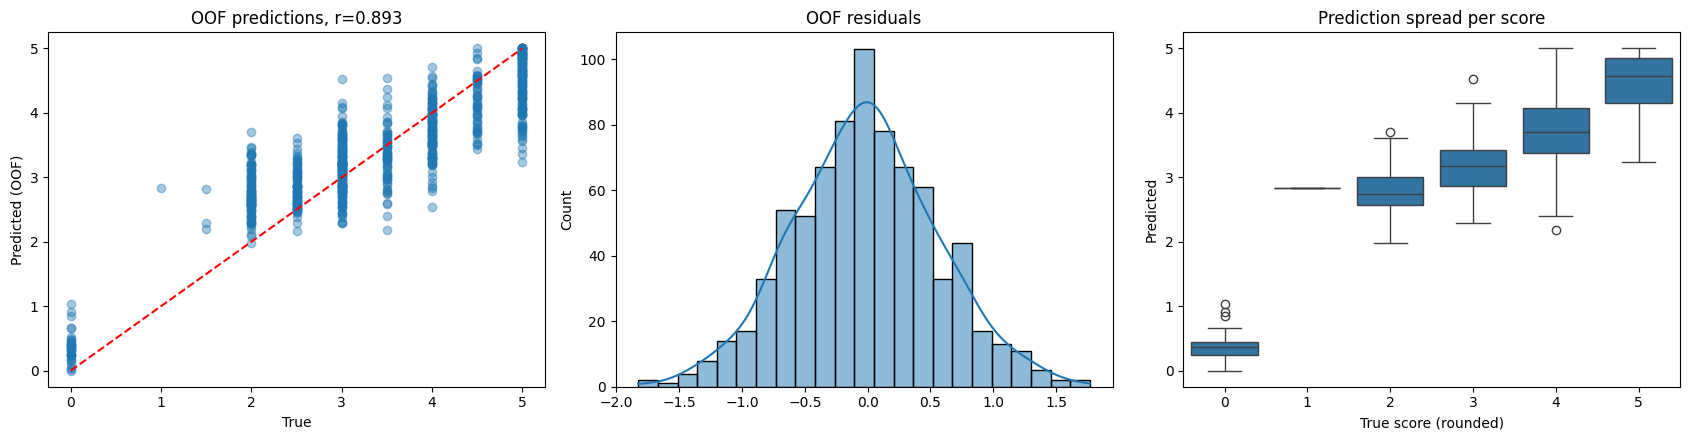

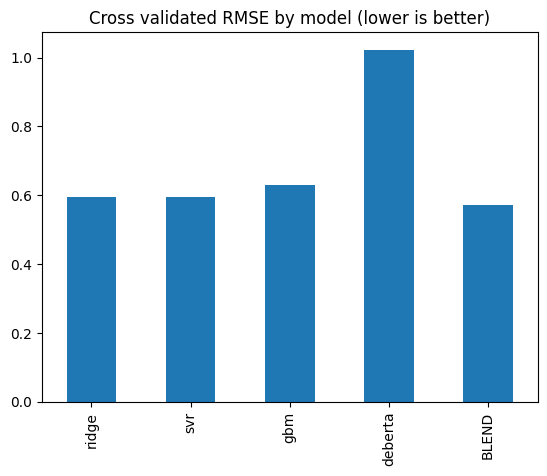

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].scatter(y, np.clip(oof_blend, 0, 5), alpha=.4); ax[0].plot([0, 5], [0, 5], "r--")
ax[0].set_xlabel("True"); ax[0].set_ylabel("Predicted (OOF)"); ax[0].set_title(f"OOF predictions, r={CV_PEARSON:.3f}")
res = y - np.clip(oof_blend, 0, 5); sns.histplot(res, kde=True, ax=ax[1]); ax[1].set_title("OOF residuals")
sns.boxplot(x=np.round(y).astype(int), y=np.clip(oof_blend, 0, 5), ax=ax[2]); ax[2].set_xlabel("True score (rounded)"); ax[2].set_ylabel("Predicted"); ax[2].set_title("Prediction spread per score")
plt.tight_layout(); plt.show()

names = list(oof.keys()) + ["BLEND"]
r = [rmse(y, np.clip(oof[k], 0, 5)) for k in oof] + [CV_RMSE]
pd.Series(r, index=names).plot.bar(title="Cross validated RMSE by model (lower is better)"); plt.show()

## 8. Submission file

In [19]:
sub_id, sub_target = sub.columns[0], sub.columns[1]
pred_map = dict(zip(test[ID_COL].map(stem), np.clip(test_blend, 0, 5)))

# File A: one row per clip in test.csv (216 rows), the data we actually have audio for.
full = pd.DataFrame({sub_id: test[ID_COL].values, sub_target: np.clip(test_blend, 0, 5)})
assert len(full) == len(test) and full[sub_target].between(0, 5).all()
full.to_csv("submission.csv", index=False)

# File B: exactly the ids listed in sample_submission.csv (204 rows).
# Ids that do not exist in test.csv get a neutral placeholder (mean prediction).
fb = sub.copy()
fb[sub_target] = fb[sub_id].map(lambda n: pred_map.get(stem(n), np.nan))
n_missing = int(fb[sub_target].isna().sum())
fb[sub_target] = fb[sub_target].fillna(float(np.mean(list(pred_map.values()))))
assert len(fb) == len(sub) and list(fb.columns) == list(sub.columns)
fb.to_csv("submission_sample_format.csv", index=False)

print("submission.csv rows:", len(full))
print("submission_sample_format.csv rows:", len(fb), "| ids with a real prediction:", len(fb) - n_missing, "| placeholders:", n_missing)
display(full.head())

submission.csv rows: 216
submission_sample_format.csv rows: 204 | ids with a real prediction: 25 | placeholders: 179


,filename,label
0,audio_128.wav,3.382530
1,audio_156.wav,4.075553
2,audio_19.wav,4.392106
3,audio_108.wav,2.255980
4,audio_206.wav,2.511500


## 9. Report

**Problem.** Predict a 0 to 5 grammar score for 45 to 60 second spoken clips. There are 769 labelled clips for training and 216 for testing. The metrics are RMSE and Pearson correlation.

**Preprocessing.** Audio is loaded at 16 kHz mono. For the audio embedding, leading and trailing silence is trimmed. Speech is converted to text with Whisper (small), giving the transcript, word timestamps and confidence values. Train and test audio are read from their own folders, because the two folders reuse some file names with different audio. Transcripts and features are cached to disk.

**Pipeline architecture.**
1. Whisper transcript and timing features (pauses, speaking rate, confidence).
2. Handcrafted text features: length, sentence statistics, vocabulary richness, fillers, repetition and connectives.
3. GPT 2 token level perplexity statistics as a grammaticality signal.
4. LanguageTool error rates per word, where available.
5. Sentence transformer embeddings of the transcript, plus wav2vec2 pooled embeddings of the audio.
6. DeBERTa v3 base fine tuned on the transcripts with a regression head, trained inside the same 5 folds as the other models.
7. Ridge, SVR, gradient boosting and DeBERTa, blended with non negative weights fitted on out of fold predictions, then clipped to the range 0 to 5.

An optional Gemini rubric grader is included in the notebook as an extra feature, but it was switched off for this run.

**Evaluation.** Stratified 5 fold cross validation gives the honest performance estimate. The compulsory training RMSE comes from the models refit on all training data. For DeBERTa, the training predictions are the average of its five fold models, each of which did not see 20 percent of the rows, so its training error is slightly less optimistic than the other models'.

| Metric | Value |
|---|---|
| Training RMSE | 0.2496 (Pearson 0.9847) |
| Cross validated RMSE | 0.5732 |
| Cross validated Pearson | 0.8924 |

The training error is lower than the cross validated error because the models have seen the training clips, so the cross validated figures are the reliable estimate of generalisation. Adding DeBERTa to the blend changed cross validated RMSE only slightly (0.5754 to 0.5732), which is within the noise expected for 769 clips, so the gain should not be overstated.

**Interpretation.** The out of fold scatter plot shows predictions following the diagonal, so the model ranks clips correctly. Predictions are pulled toward the middle at the extremes, which is expected when a regression model is optimised for RMSE and cannot predict outside the range 0 to 5. The residuals are centred on zero and roughly bell shaped, so the model does not systematically over or under score. The box plot shows the median prediction rising steadily from score 0 to score 5, and score 0 clips are predicted almost perfectly. Score 1 has very few samples, so its box is not meaningful. The bar chart shows the blend performing at least as well as every single model, which justifies the ensemble. The feature correlation chart shows which handcrafted signals relate most strongly to the score, typically perplexity, filler and repetition rates, sentence structure and ASR confidence.

**Limitations and next steps.** ASR errors can be mistaken for grammar errors, and Whisper sometimes silently corrects speech, which hides real mistakes. With only 769 training clips and an imbalanced label distribution, the extremes of the scale are hard to predict. Ideas to improve the score: enable the Gemini grader feature, use a larger Whisper model, fine tune wav2vec2 or the Whisper encoder directly on the audio, and average over several cross validation seeds.